# 05 — Bollinger Bands and Volatility

## What you'll learn
- What **Bollinger Bands** are: a moving average with a volatility-scaled envelope.
- How to read **%B** — where the price sits *inside* its band, on a 0–1 scale.
- How to read **bandwidth** — the width of the band relative to price, and what a "squeeze" hints at.
- What **ATR (Average True Range)** measures, and why it is an *absolute* (dollar) volatility that differs from the *relative* standard deviation inside Bollinger bands.
- The honest limits: bands describe volatility and location, **not direction**.

We build on the hand-computed indicators in `stocklearn.indicators` — no indicator library, so you can see exactly what each number means.

## Setup

We import the package, set a chart style, and define a single `ticker` (and `period`) variable at the top.
**To study a different company, change `ticker` here and re-run the notebook.** Every cell below uses it.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from stocklearn.data import get_history, price_series
from stocklearn.indicators import bollinger, atr, annualized_volatility

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

ticker = "AAPL"
period = "1y"

## 1. Bollinger Bands — a moving average with a volatility envelope

A Bollinger band is just three lines:

$$
\text{middle} = \text{SMA}_{20}(\text{price}), \qquad
\text{upper/lower} = \text{middle} \pm 2 \cdot \sigma_{20}
$$

where $\sigma_{20}$ is the rolling 20-day **standard deviation** of price. The default is a 20-day window and 2 standard deviations.

**Why it matters:** the band width is *not fixed* — it is driven by how much the price has recently moved. When the market gets jumpy, $\sigma_{20}$ rises and the bands **widen**; when it calms down, they **narrow**. So the band is really a picture of recent volatility wrapped around a trend line.

Below we fetch adjusted prices and overlay the bands on the price.

In [2]:
df = get_history(ticker, period=period)
close = price_series(df)          # adjusted close — splits/dividends already handled
bb = bollinger(close)             # columns: middle, upper, lower

df.tail(3)

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
2026-09-30 00:00:00-04:00,330.80,339.50,330.14,333.02,333.02,49988600,0.00,0.00
2026-10-01 00:00:00-04:00,330.00,332.48,325.81,330.32,330.32,36306300,0.00,0.00
2026-10-02 00:00:00-04:00,333.26,334.54,330.61,333.69,333.69,33245500,0.00,0.00


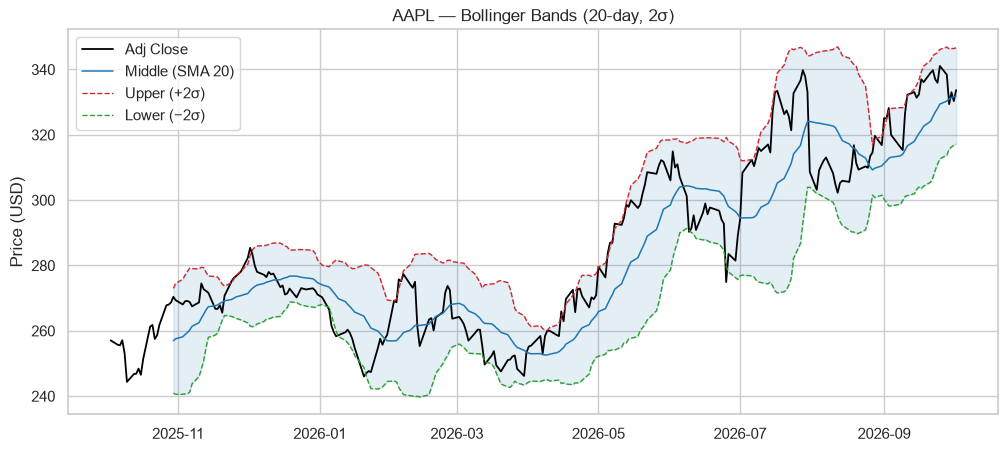

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(close.index, close, color="black", lw=1.3, label="Adj Close")
ax.plot(bb.index, bb["middle"], color="tab:blue", lw=1.1, label="Middle (SMA 20)")
ax.plot(bb.index, bb["upper"], color="tab:red", lw=1.0, ls="--", label="Upper (+2σ)")
ax.plot(bb.index, bb["lower"], color="tab:green", lw=1.0, ls="--", label="Lower (−2σ)")
ax.fill_between(bb.index, bb["lower"], bb["upper"], color="tab:blue", alpha=0.12)

ax.set_title(f"{ticker} — Bollinger Bands (20-day, 2σ)")
ax.set_ylabel("Price (USD)")
ax.legend(loc="upper left")
plt.show()

**Reading it:** roughly 95% of the time, price sits *between* the two bands if returns were normal — but real prices have fatter tails, so "touching" a band is much more common than the 2σ statistic suggests. Notice how the band pinches and stretches along the chart: that stretch is pure volatility.

**Common pitfall:** a touch of the upper band is **not** a sell signal. In a strong uptrend price can "walk the band" for weeks. Bands tell you *how volatile* and *where* price sits — never *which way* it will go next.

## 2. %B — where is the price inside the band?

$\%B$ rescales the position of price inside the band onto a clean 0–1 axis:

$$
\%B = \frac{\text{close} - \text{lower}}{\text{upper} - \text{lower}}
$$

- $\%B = 1$ → price is at the **upper** band.
- $\%B = 0.5$ → price is exactly on the **middle** (the 20-day average).
- $\%B = 0$ → price is at the **lower** band.
- Values **below 0 or above 1** mean price has actually closed *outside* the band — a sign of unusual momentum.

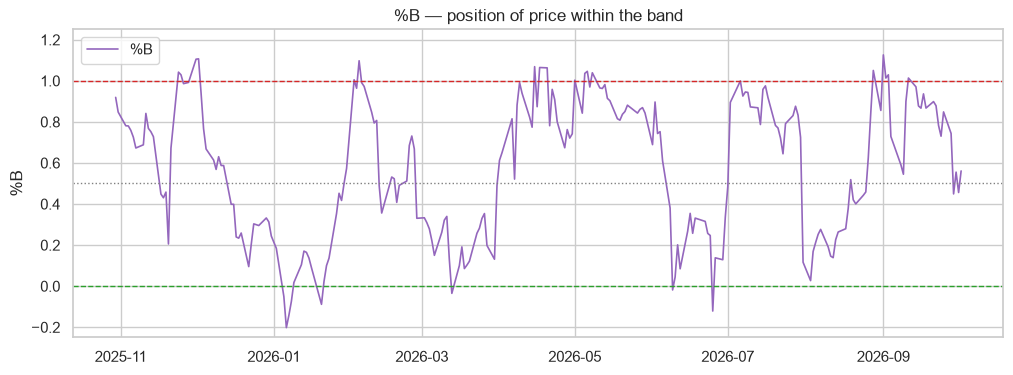

In [4]:
pct_b = (close - bb["lower"]) / (bb["upper"] - bb["lower"])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(pct_b.index, pct_b, color="tab:purple", lw=1.2, label="%B")
ax.axhline(1.0, color="tab:red", ls="--", lw=1.0)
ax.axhline(0.5, color="gray", ls=":", lw=1.0)
ax.axhline(0.0, color="tab:green", ls="--", lw=1.0)
ax.set_ylim(-0.25, 1.25)
ax.set_title("%B — position of price within the band")
ax.set_ylabel("%B")
ax.legend(loc="upper left")
plt.show()

**Reading it:** %B compresses "price vs volatility" into one number, which makes it easy to scan. Long stretches pinned near 1 = persistent strength (or an over-extended move); near 0 = persistent weakness. Spikes above 1 or below 0 are the moments price broke out of its recent volatility envelope — often momentum, not a reversal.

**Pitfall:** %B is *relative*. The same %B = 0.9 means a very different dollar move in a quiet stock versus a wild one, because the band width itself changed.

## 3. Bandwidth — the squeeze

Bandwidth normalises the band's dollar width by the middle line, so it becomes comparable across time and across stocks:

$$
\text{bandwidth} = \frac{\text{upper} - \text{lower}}{\text{middle}}
$$

A **low or falling bandwidth** is called a *squeeze*: recent volatility is unusually small. Traders watch squeezes because low volatility is often followed by a **larger move** — but note the crucial caveat: **the squeeze does not say which direction**. It is a volatility statement, not a directional one.

A **high/rising bandwidth** simply means the market is already moving a lot.

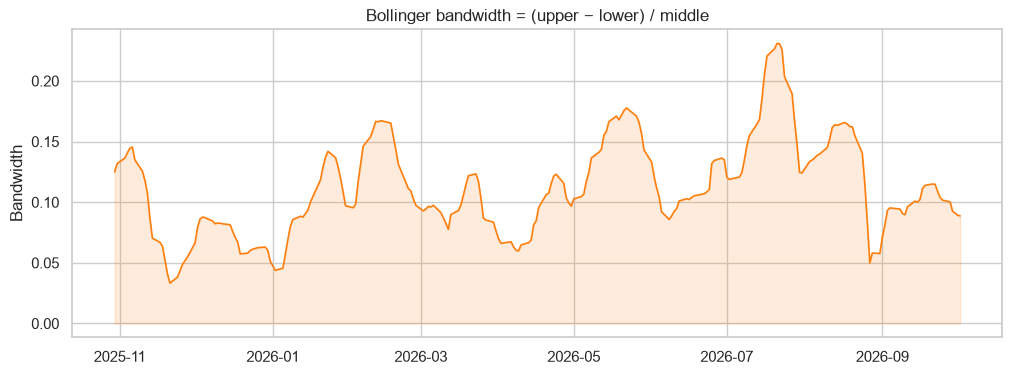

In [5]:
bandwidth = (bb["upper"] - bb["lower"]) / bb["middle"]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(bandwidth.index, bandwidth, color="tab:orange", lw=1.2)
ax.fill_between(bandwidth.index, bandwidth, color="tab:orange", alpha=0.15)
ax.set_title("Bollinger bandwidth = (upper − lower) / middle")
ax.set_ylabel("Bandwidth")
plt.show()

**Reading it:** compare the bandwidth plot with the price chart above. The narrow troughs are the quiet periods; the peaks line up with the fast, wide-swinging stretches. If you want to *trade* a squeeze, the honest approach is to wait for the breakout and then follow it — the band itself gives you no prior.

## 4. ATR — absolute (dollar) volatility

Average True Range answers a different question: *how many dollars does this stock typically move in a day?*

First define the **true range** of a bar, which accounts for overnight gaps:

$$
TR_t = \max\big(H_t - L_t,\; |H_t - C_{t-1}|,\; |L_t - C_{t-1}|\big)
$$

Then `ATR = EMA(TR, period)` (Wilder's smoothing, `alpha = 1/period`). Unlike Bollinger's $\sigma$, which is measured around a *mean price* and is dimensionless (relative), ATR is reported in **dollars** and is an absolute measure of range. We compute it from the *raw* high/low/close columns, because gaps are what true range is designed to capture.

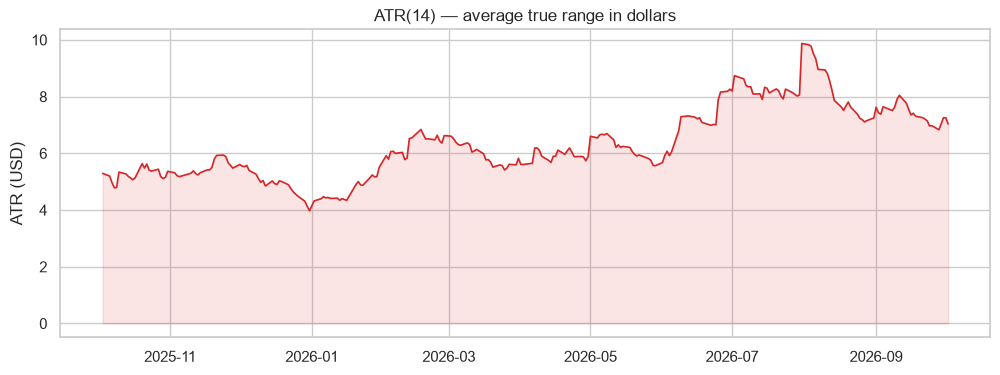

In [6]:
atr14 = atr(df["High"], df["Low"], df["Close"])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(atr14.index, atr14, color="tab:red", lw=1.2)
ax.fill_between(atr14.index, atr14, color="tab:red", alpha=0.12)
ax.set_title("ATR(14) — average true range in dollars")
ax.set_ylabel("ATR (USD)")
plt.show()

**Bollinger's σ vs ATR** — same idea (recent volatility), different units and construction:

| | Bollinger σ | ATR |
|---|---|---|
| Units | relative to price (dimensionless) | dollars (absolute) |
| Built from | close-to-close spread around a mean | high/low/close *range*, including gaps |
| Good for | band position (%B), squeezes | position sizing, stop distance, comparing dollar risk |

Use ATR when you care about the *size of a move in dollars* (e.g. "a 2×ATR stop"); use Bollinger when you care about *where price sits relative to its own recent noise*.

In [7]:
last_atr = atr14.dropna().iloc[-1]
print(f"{ticker} — the two volatility rulers side by side")
print(f"  Relative: annualized volatility = {annualized_volatility(close):.1%} (unitless)")
print(f"  Absolute: ATR(14)               = ${last_atr:,.2f} per day")

AAPL — the two volatility rulers side by side
  Relative: annualized volatility = 24.7% (unitless)
  Absolute: ATR(14)               = $7.03 per day


## 5. Mean reversion vs breakout — two ways to read the same band

The *same* band touch supports two opposite stories, and both are legitimate hypotheses — that is exactly why the band alone cannot be a signal:

- **Mean-reversion reading.** Bands are a rubber band: price stretched to the upper (or lower) band *tends to snap back* toward the middle. The trade idea is to fade the extreme, betting on a return to the average. This works best in **range-bound** markets.
- **Breakout reading.** A close *outside* the band means momentum is strong and a new trend may be starting. The trade idea is to follow the move. This works best in **trending** markets.

Which regime you are in is not visible in the band — you need extra context (trend, volume, news, higher-timeframe structure).

**The honest caveat:** Bollinger bands, %B, bandwidth and ATR are all **volatility and location** measures. They say *how much* and *where*, never *which way*. A squeeze raises the odds of a big move but is silent on direction; a band touch can mean reversal or acceleration. Treat every reading as context for a thesis, never as a forecast.

## Recap / try this
- **Swap the ticker.** Set `ticker = "MSFT"` (or a volatile small-cap) and re-run. Compare the bandwidth *level* — high-volatility names carry wider bands and larger ATRs at the same %B.
- **Change the window.** Try `bollinger(close, window=50, num_std=2)`. A longer window reacts more slowly; the bands will look smoother and crossings rarer.
- **Tune the squeeze detector.** Count how many days `bandwidth` was below its own 20-day 20th percentile. Do big moves follow those squeezes *in this sample*, and in which direction?
- **Use ATR for sizing.** Compute `2 * atr14` and compare it to the stock's daily candle sizes. This is how ATR is used in practice: to set stops and size positions to a fixed dollar risk.

> Educational analysis only — not financial advice.